<a href="https://colab.research.google.com/github/burgerman/credit_risk_modelling/blob/master/Credit_Risk_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install pyod -q
!pip install optuna -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 12.3 MB/s eta 0:00:00


In [ ]:
import sys
import pandas as pd
import numpy as np
import warnings

# plot
import matplotlib.pyplot as plt
import seaborn as sns
# outlier detection
from scipy.stats import median_abs_deviation
from pyod.models.mad import MAD

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
# feature selection
import shap
from sklearn.feature_selection import f_classif, chi2
from sklearn.feature_selection import RFECV, RFE
# models
import xgboost as xgb
import lightgbm as lgb

# hypertuning
import optuna

# model_selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# model validation
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, average_precision_score, confusion_matrix, precision_recall_fscore_support
from sklearn.calibration import calibration_curve
from scipy.stats import ks_2samp

sys.path.append('/content/drive/MyDrive/DataScience/Risk/credit_risk_modeling')

In [ ]:
def dataframe_description(df):
    """
    basic info of tabular data.
    """
    categorical_features = []
    continuous_features = []
    binary_features = []

    for col in df.columns:
        if df[col].dtype == object:
            categorical_features.append(col)
        else:
            if df[col].nunique() <= 2:
                binary_features.append(col)
            else:
                continuous_features.append(col)

    print("\n{} shape: {}".format(type(df).__name__, df.shape))
    print("\n{:,.0f} data rows".format(df.shape[0]))
    print("\n{:,.0f} features".format(df.shape[1]))
    print(f'\nMissing Data: \n')
    print(df.isnull().sum())
    print(f'\nDuplicates: {df.duplicated().sum()}')
    print(f'\nData types: \n')
    print(df.dtypes)
    print(f'\nCategorical features: \n')
    if len(categorical_features) == 0:
        print('No Categorical Features')
    else:
        for feature in categorical_features:
            print(feature)
    print(f'\nContinuous features: \n')
    if len(continuous_features) == 0:
        print('No Continuous Features')
    else:
        for feature in continuous_features:
            print(feature)
    print(f'\nBinary features: \n')
    if len(binary_features) == 0:
        print('No Binary Features')
    else:
        for feature in binary_features:
            print(feature)
    print(f'\n{type(df).__name__} Head: \n')
    display(df.head(5))

In [ ]:
var_list = ['Client_ID','Loan_Request','MTG_Due','Property_Value','Loan_Reason','Occupation','Years_At_Job','Derog_Report','DELQ_Line','Trade_Line','File_Age','Inquiry','Debt_Income_Ratio', 'Bad']
ld_df = pd.read_csv('/content/drive/MyDrive/DataScience/Risk/credit_risk_modeling/Loan_Default_Data.csv', usecols=var_list, delimiter='\x7c', encoding='utf-8')
print("\nSummary of DataFrame:")
print(ld_df.info())
print(dataframe_description(ld_df))


Summary of DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10663 entries, 0 to 10662
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Client_ID          10663 non-null  object 
 1   Loan_Request       10663 non-null  object 
 2   MTG_Due            9720 non-null   object 
 3   Property_Value     10458 non-null  object 
 4   Loan_Reason        10206 non-null  object 
 5   Occupation         10157 non-null  object 
 6   Years_At_Job       9731 non-null   float64
 7   Derog_Report       9384 non-null   float64
 8   DELQ_Line          9625 non-null   float64
 9   Trade_Line         10254 non-null  float64
 10  File_Age           10103 non-null  float64
 11  Inquiry            9744 non-null   float64
 12  Debt_Income_Ratio  8391 non-null   float64
 13  Bad                10663 non-null  int64  
dtypes: float64(7), int64(1), object(6)
memory usage: 1.1+ MB
None

DataFrame shape: (10663, 14)

10

,Client_ID,Loan_Request,MTG_Due,Property_Value,Loan_Reason,Occupation,Years_At_Job,Derog_Report,DELQ_Line,Trade_Line,File_Age,Inquiry,Debt_Income_Ratio,Bad
0,ID#00001,"$1,100","$25,860","$39,025",HomeImp,Other,10.5,0.0,0.0,9.0,94.4,1.0,NaN,1
1,ID#00002,"$1,300","$70,053","$68,400",HomeImp,Other,7.0,0.0,2.0,14.0,121.8,0.0,NaN,1
2,ID#00003,"$1,500","$13,500","$16,700",HomeImp,Other,4.0,0.0,0.0,10.0,149.5,1.0,NaN,1
3,ID#00004,"$1,500",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,ID#00005,"$1,700","$97,800","$112,000",HomeImp,Office,3.0,0.0,0.0,14.0,93.3,0.0,NaN,0


None


In [ ]:
ld_df['Loan_Request'] = ld_df['Loan_Request'].astype(str).str.replace('$', '').str.replace(',', '').str.strip()
# convert to numeric
ld_df['Loan_Request'] = pd.to_numeric(ld_df['Loan_Request'], errors='coerce')

ld_df['Property_Value'] = ld_df['Property_Value'].astype(str).str.replace('$', '').str.replace(',', '').str.strip()
# convert to numeric
ld_df['Property_Value'] = pd.to_numeric(ld_df['Property_Value'], errors='coerce')

ld_df['MTG_Due'] = ld_df['MTG_Due'].astype(str).str.replace('$', '').str.replace(',', '').str.strip()
# convert to numeric
ld_df['MTG_Due'] = pd.to_numeric(ld_df['MTG_Due'], errors='coerce')

In [ ]:
num_features = [col for col in ld_df.columns if ld_df[col].dtype in ['float64']]
print(f"numeric features: {num_features}")

numeric features: ['MTG_Due', 'Property_Value', 'Years_At_Job', 'Derog_Report', 'DELQ_Line', 'Trade_Line', 'File_Age', 'Inquiry', 'Debt_Income_Ratio']


In [ ]:
# ANOVA tests(F-test) for Numeric Features
ano_df = ld_df[num_features+['Bad']].dropna(inplace=False)
X_num = ano_df[num_features]
y = ano_df['Bad']
F_values, p_values = f_classif(X_num, y)
anova_results = pd.DataFrame({
    "Feature": num_features,
    "F_value": F_values,
    "p_value": p_values
}).sort_values("p_value")
print(anova_results)

             Feature     F_value        p_value
4          DELQ_Line  530.075735  1.132695e-112
3       Derog_Report  448.171424   3.870524e-96
8  Debt_Income_Ratio  360.070717   4.039179e-78
7            Inquiry   86.885453   1.559555e-20
6           File_Age   75.815488   3.931803e-18
2       Years_At_Job   29.368108   6.208221e-08
1     Property_Value    4.212729   4.016310e-02
0            MTG_Due    1.030970   3.099701e-01
5         Trade_Line    0.478237   4.892477e-01


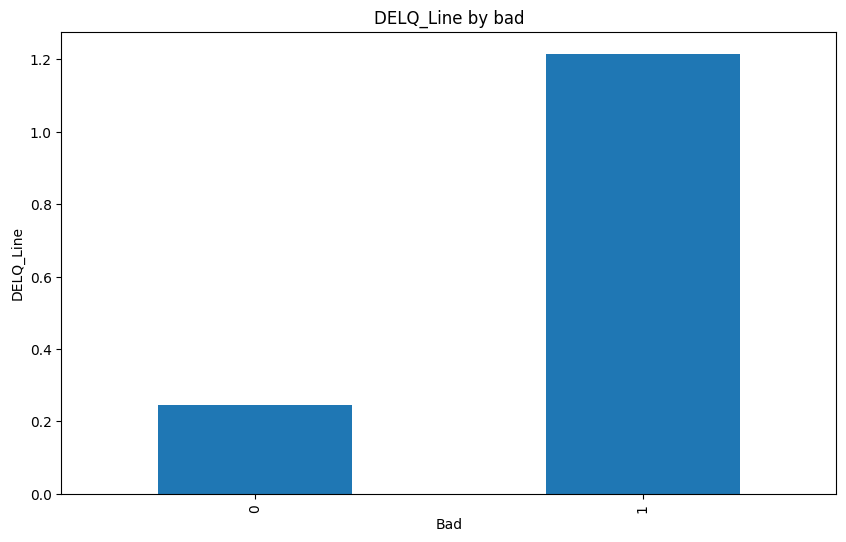

In [ ]:
DELQ_Line_by_bad = ld_df.groupby(['Bad'])['DELQ_Line'].mean()
DELQ_Line_by_bad.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Bad')
plt.ylabel('DELQ_Line')
plt.title('DELQ_Line by bad')
plt.show()

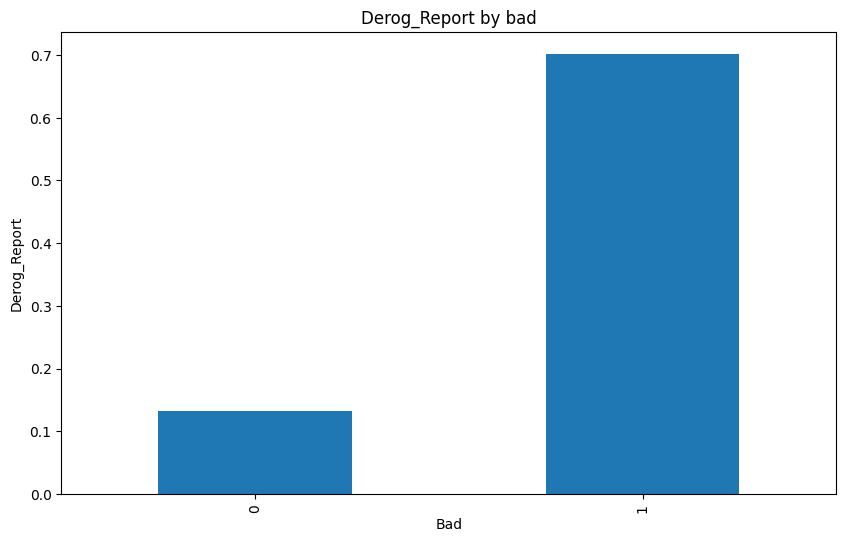

In [ ]:
Derog_Report_by_bad = ld_df.groupby(['Bad'])['Derog_Report'].mean()
Derog_Report_by_bad.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Bad')
plt.ylabel('Derog_Report')
plt.title('Derog_Report by bad')
plt.show()

In [ ]:
correlation_matrix = ano_df.corr()
correlation_with_target = correlation_matrix['Bad']
print(correlation_with_target)

MTG_Due             -0.012814
Property_Value      -0.025896
Years_At_Job        -0.068236
Derog_Report         0.258130
DELQ_Line            0.279034
Trade_Line           0.008728
File_Age            -0.109235
Inquiry              0.116836
Debt_Income_Ratio    0.232902
Bad                  1.000000
Name: Bad, dtype: float64


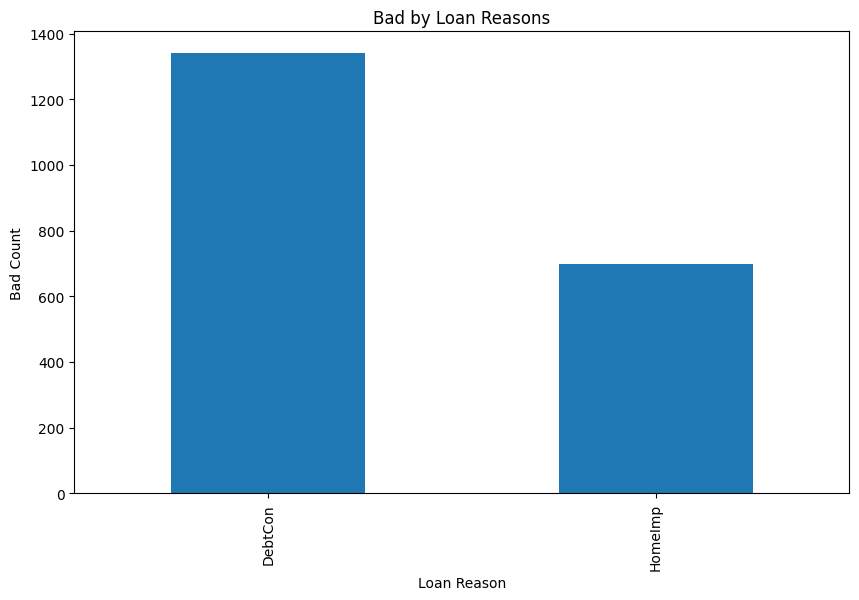

In [ ]:
bad_by_intent = ld_df.groupby(['Loan_Reason'])['Bad'].sum()
bad_by_intent.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Loan Reason')
plt.ylabel('Bad Count')
plt.title('Bad by Loan Reasons')
plt.show()

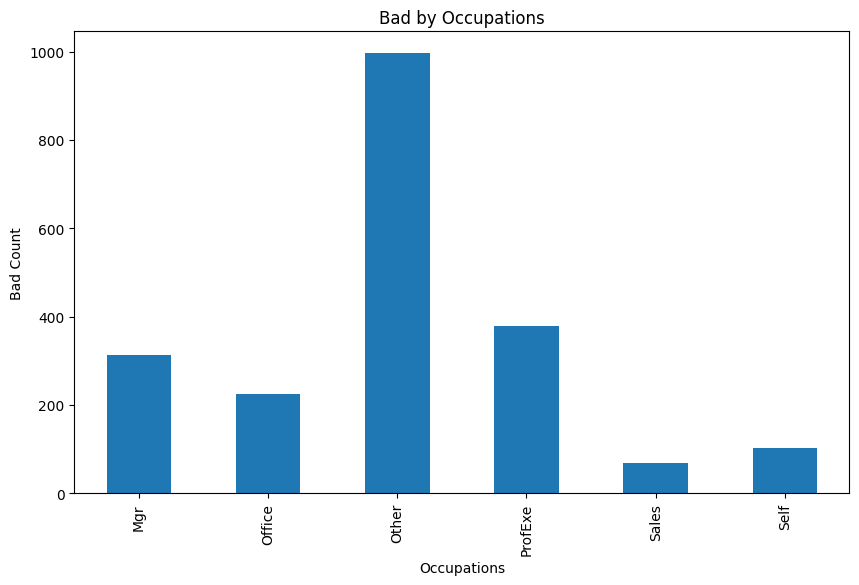

In [ ]:
bad_by_occupation = ld_df.groupby(['Occupation'])['Bad'].sum()
bad_by_occupation.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Occupations')
plt.ylabel('Bad Count')
plt.title('Bad by Occupations')
plt.show()

In [ ]:
# fill Null with Other
# ld_df['Occupation'] = ld_df['Occupation'].fillna('Other')
# fill Null with mode
# ld_df['Loan_Reason'] = ld_df['Loan_Reason'].fillna(ld_df['Loan_Reason'].mode()[0])
# print(ld_df['Loan_Reason'].nunique())
# print(ld_df['Occupation'].nunique())

In [ ]:
encoder = LabelEncoder()
cat_features = ['Loan_Reason', 'Occupation']
chi_square_df = ld_df[cat_features+['Bad']].dropna(inplace=False)
y = chi_square_df['Bad']
X_cat = chi_square_df[cat_features].apply(lambda col: encoder.fit_transform(col.astype(str)))
chi2_values, chi2_p = chi2(X_cat, y)

chi2_results = pd.DataFrame({
    "Feature": cat_features,
    "Chi2_value": chi2_values,
    "p_value": chi2_p
}).sort_values("p_value")
print(chi2_results)

       Feature  Chi2_value   p_value
0  Loan_Reason    8.902248  0.002848
1   Occupation    2.500762  0.113791


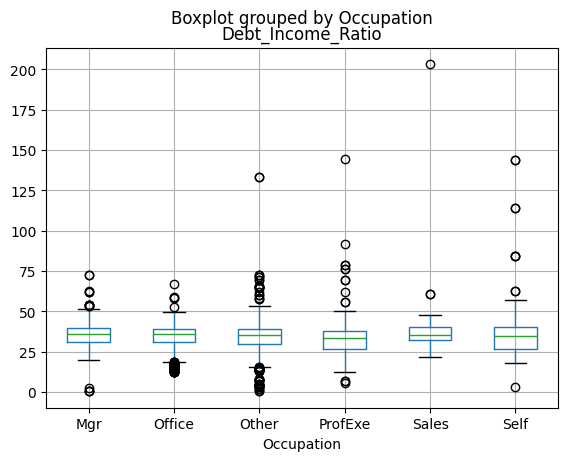

In [ ]:
ld_df.boxplot(column=['Debt_Income_Ratio'], by='Occupation')
plt.title('Debt_Income_Ratio')
plt.show()

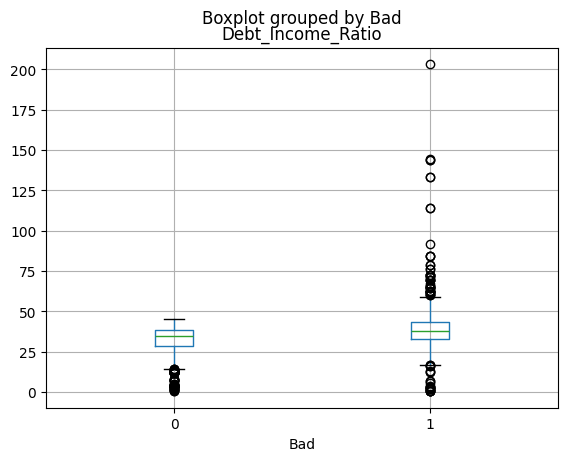

count    8391.000000
mean       33.765463
std         8.379086
min         0.500000
25%        29.100000
50%        34.900000
75%        39.000000
max       203.300000
Name: Debt_Income_Ratio, dtype: float64


In [ ]:
ld_df.boxplot(column=['Debt_Income_Ratio'], by='Bad')
plt.title('Debt_Income_Ratio')
plt.show()
print(ld_df['Debt_Income_Ratio'].describe())

In [ ]:
# sns.pairplot(data=ld_df, vars=["MTG_Due", "Loan_Request", "Property_Value", "Debt_Income_Ratio"])
# plt.show()

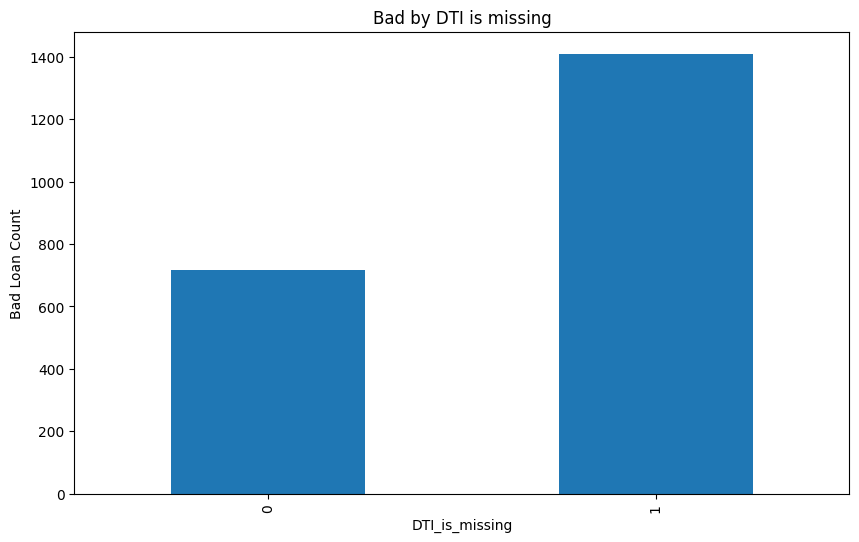

In [ ]:
# feature engineering for data missing
ld_df['DTI_is_missing'] = ld_df['Debt_Income_Ratio'].isnull().astype(int)
bad_by_DTI_is_missing = ld_df.groupby(['DTI_is_missing'])['Bad'].sum()
bad_by_DTI_is_missing.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('DTI_is_missing')
plt.ylabel('Bad Loan Count')
plt.title('Bad by DTI is missing')
plt.show()

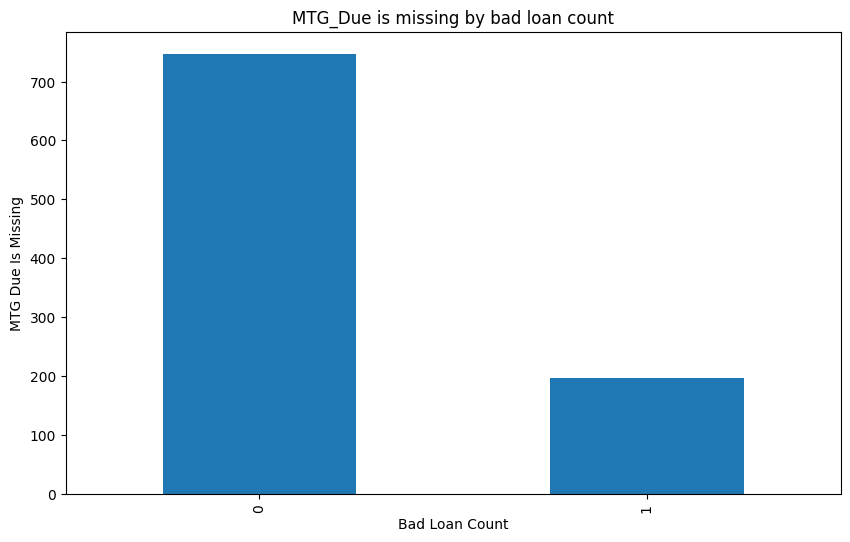

In [ ]:
ld_df['MTG_Due_is_missing'] = ld_df['MTG_Due'].isnull().astype(int)
MTG_Due_is_missing_by_bad = ld_df.groupby(['Bad'])['MTG_Due_is_missing'].sum()
MTG_Due_is_missing_by_bad.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.ylabel('MTG Due Is Missing')
plt.xlabel('Bad Loan Count')
plt.title('MTG_Due is missing by bad loan count')
plt.show()

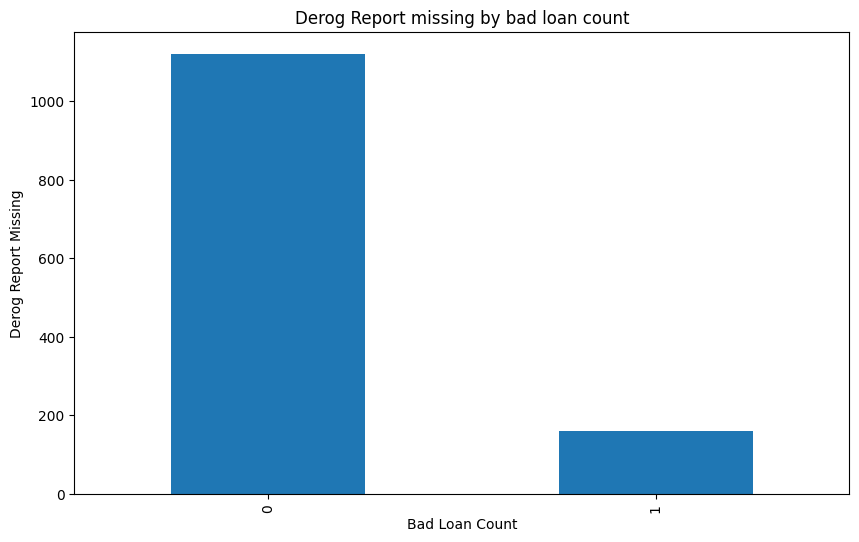

In [ ]:
ld_df['Derog_Report_is_missing'] = ld_df['Derog_Report'].isnull().astype(int)
Derog_Report_is_missing_by_bad = ld_df.groupby(['Bad'])['Derog_Report_is_missing'].sum()
Derog_Report_is_missing_by_bad.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.ylabel('Derog Report Missing')
plt.xlabel('Bad Loan Count')
plt.title('Derog Report missing by bad loan count')
plt.show()

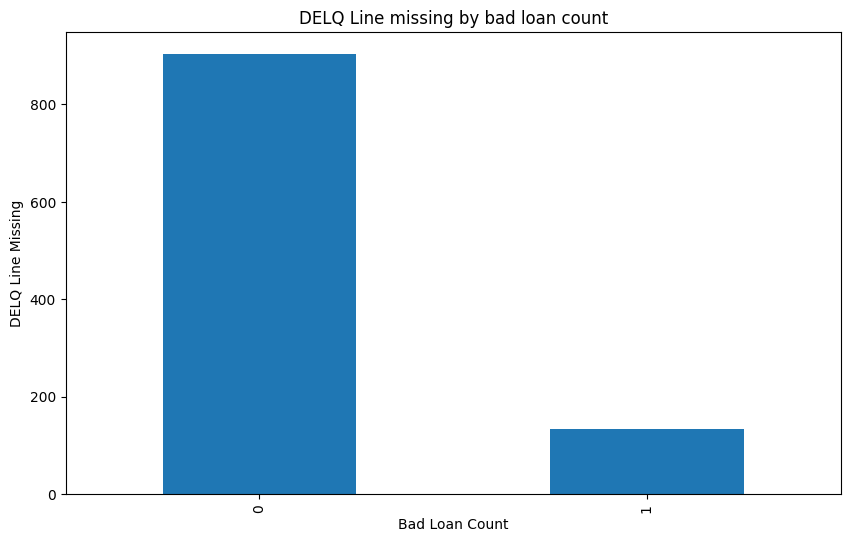

In [ ]:
ld_df['DELQ_Line_is_missing'] = ld_df['DELQ_Line'].isnull().astype(int)
DELQ_Line_is_missing_by_bad = ld_df.groupby(['Bad'])['DELQ_Line_is_missing'].sum()
DELQ_Line_is_missing_by_bad.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.ylabel('DELQ Line Missing')
plt.xlabel('Bad Loan Count')
plt.title('DELQ Line missing by bad loan count')
plt.show()

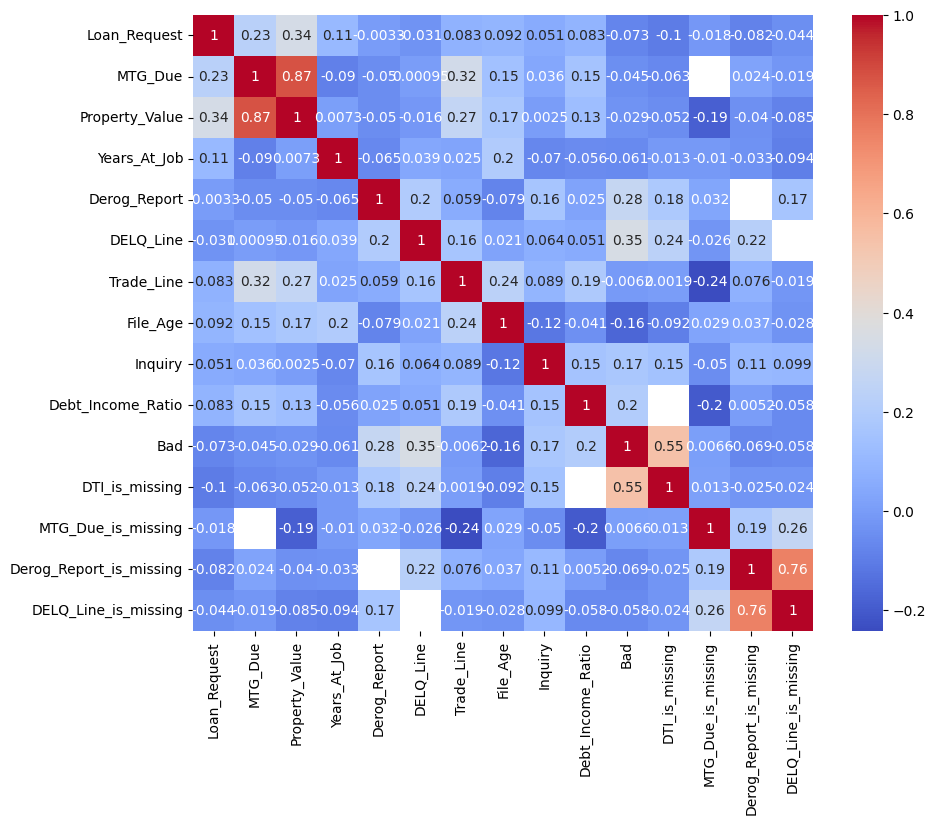

In [ ]:
corr_matrix = ld_df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()
# Property_Value and MTG_Due are highly correlated. MTG_Due includes more missing data (943 : 205)

In [ ]:
# delete extra features
del ld_df['DTI_is_missing']
# del ld_df['MTG_Due_is_missing']
# del ld_df['Derog_Report_is_missing']
del ld_df['DELQ_Line_is_missing']
# del ld_df ['File_Age_is_missing']

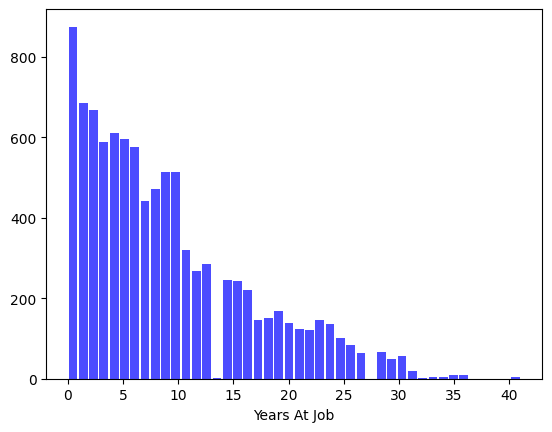

count    9731.000000
mean        8.924843
std         7.588757
min         0.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        41.000000
Name: Years_At_Job, dtype: float64


In [ ]:
n, bins, patches = plt.hist(x=ld_df['Years_At_Job'], bins='auto', color='blue',alpha=0.7, rwidth=0.85)
plt.xlabel("Years At Job")
plt.show()
print(ld_df['Years_At_Job'].describe())

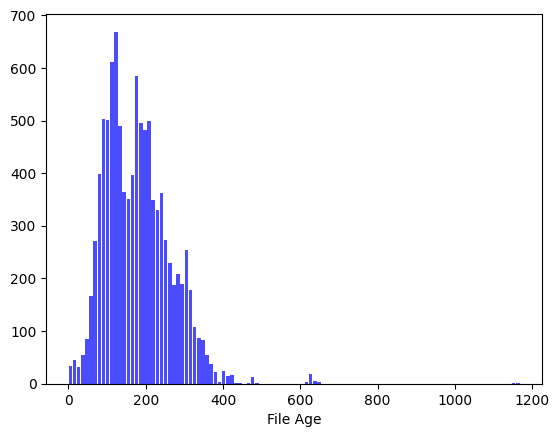

count    10103.000000
mean       179.648530
std         86.032306
min          0.000000
25%        114.950000
50%        173.300000
75%        230.950000
max       1168.200000
Name: File_Age, dtype: float64


In [ ]:
n, bins, patches = plt.hist(x=ld_df['File_Age'], bins='auto', color='blue',alpha=0.7, rwidth=0.85)
plt.xlabel("File Age")
plt.show()
print(ld_df['File_Age'].describe())

In [ ]:
# File_Age_dict = ld_df.groupby(['Bad'])['File_Age'].median().to_dict()
# print(File_Age_dict)
# print(ld_df['File_Age'].median())
# ld_df['File_Age'] = ld_df['File_Age'].fillna(ld_df['Bad'].map(File_Age_dict))

# Years_At_Job_dict = ld_df.groupby(['Bad'])['Years_At_Job'].median().to_dict()
# print(Years_At_Job_dict)
# print(ld_df['Years_At_Job'].median())
# ld_df['Years_At_Job'] = ld_df['Years_At_Job'].fillna(ld_df['Bad'].map(Years_At_Job_dict))

In [ ]:
# Derog_Report_dict = ld_df.groupby(['Bad'])['Derog_Report'].median().to_dict()
# print(Derog_Report_dict)

# DELQ_Line_dict = ld_df.groupby(['Bad'])['DELQ_Line'].median().to_dict()
# print(DELQ_Line_dict)

# ld_df['Derog_Report'] = ld_df['Derog_Report'].fillna(ld_df['Derog_Report'].median())
# ld_df['DELQ_Line'] = ld_df['DELQ_Line'].fillna(ld_df['DELQ_Line'].median())

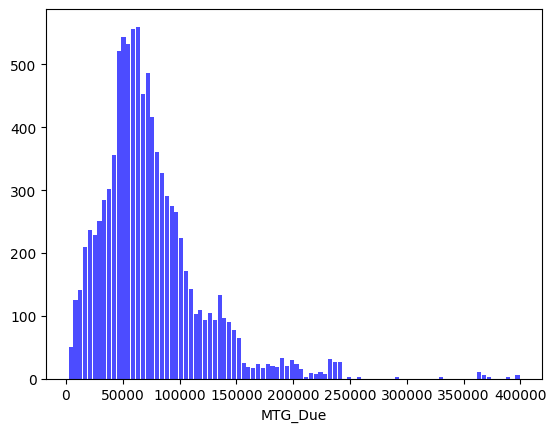

count      9720.000000
mean      73858.692078
std       44782.257047
min        2063.000000
25%       46336.500000
50%       65014.500000
75%       91688.250000
max      399550.000000
Name: MTG_Due, dtype: float64
non-default median:
66817.0


In [ ]:
n, bins, patches = plt.hist(x=ld_df['MTG_Due'], bins='auto', color='blue',alpha=0.7, rwidth=0.85)
plt.xlabel("MTG_Due")
plt.show()
print(ld_df['MTG_Due'].describe())
print("non-default median:")
print(ld_df[ld_df['Bad']==0]['MTG_Due'].median())

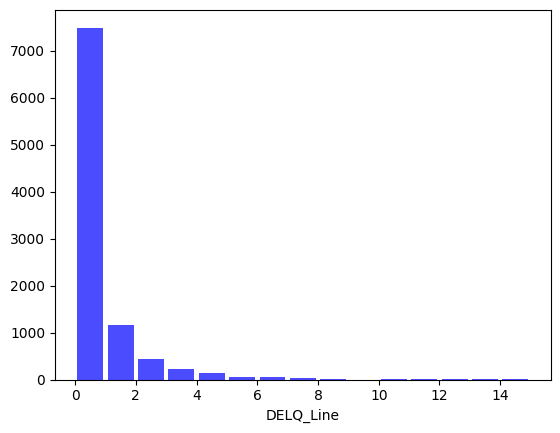

count    9625.000000
mean        0.445091
std         1.125317
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        15.000000
Name: DELQ_Line, dtype: float64


In [ ]:
n, bins, patches = plt.hist(x=ld_df['DELQ_Line'], bins='auto', color='blue',alpha=0.7, rwidth=0.85)
plt.xlabel("DELQ_Line")
plt.show()
print(ld_df['DELQ_Line'].describe())

In [ ]:
Derog_Report_dict = ld_df.groupby(['Bad'])['Derog_Report'].median().to_dict()
print(Derog_Report_dict)

DELQ_Line_dict = ld_df.groupby(['Bad'])['DELQ_Line'].median().to_dict()
print(DELQ_Line_dict)

# ld_df['Derog_Report'] = ld_df['Derog_Report'].fillna(ld_df['Derog_Report'].median())
# ld_df['DELQ_Line'] = ld_df['DELQ_Line'].fillna(ld_df['DELQ_Line'].median())

{0: 0.0, 1: 0.0}
{0: 0.0, 1: 0.0}


In [ ]:
# Log Transform - help the model find more subtle split points in the non-zero range
# ld_df['DELQ_Line'] = np.log1p(ld_df['DELQ_Line'])
# ld_df['Derog_Report'] = np.log1p(ld_df['Derog_Report'])

In [ ]:
Inquiry_dict = ld_df.groupby(['Bad'])['Inquiry'].median().to_dict()
print(Inquiry_dict)
# ld_df['Inquiry'] = ld_df['Inquiry'].fillna(ld_df['Inquiry'].median())
# ld_df['Inquiry'] = np.log1p(ld_df['Inquiry'])

{0: 1.0, 1: 1.0}


In [ ]:
# mad = MAD(threshold=3.5)
# Property_Value_reshaped = ld_df['Property_Value'].values.reshape(-1, 1)
# Property_Value_outlier_labels = mad.fit_predict(Property_Value_reshaped)
# print(Property_Value_outlier_labels)
# print(Property_Value_outlier_labels.sum())
# Property_Value_outlier_mask = (Property_Value_outlier_labels == 1)
# ld_df = ld_df[~Property_Value_outlier_mask]
# ld_df = ld_df.reset_index(drop=True)


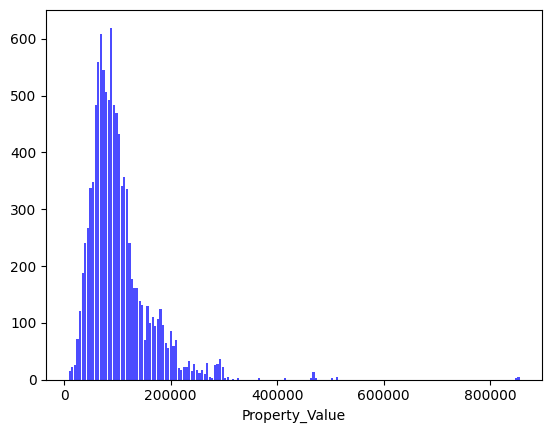

count     10458.000000
mean     101601.505259
std       57570.410021
min        8000.000000
25%       65963.000000
50%       89002.500000
75%      119526.250000
max      855909.000000
Name: Property_Value, dtype: float64
non-default median:
90435.0


In [ ]:
n, bins, patches = plt.hist(x=ld_df['Property_Value'], bins='auto', color='blue',alpha=0.7, rwidth=0.85)
plt.xlabel("Property_Value")
plt.show()
print(ld_df['Property_Value'].describe())
print("non-default median:")
print(ld_df[ld_df['Bad']==0]['Property_Value'].median())

In [ ]:
# ld_df = ld_df.dropna(subset=['Property_Value', 'Trade_Line'], inplace=False)

ld_df = ld_df.dropna(subset=['Property_Value'], inplace=False)
ld_df = ld_df.reset_index(drop=True)

In [ ]:
print(f'\nMissing Data: \n')
print(ld_df.isnull().sum())


Missing Data: 

Client_ID                     0
Loan_Request                  0
MTG_Due                     890
Property_Value                0
Loan_Reason                 418
Occupation                  473
Years_At_Job                909
Derog_Report               1228
DELQ_Line                   993
Trade_Line                  375
File_Age                    524
Inquiry                     883
Debt_Income_Ratio          2124
Bad                           0
MTG_Due_is_missing            0
Derog_Report_is_missing       0
dtype: int64


In [ ]:
# Binning for Debt_Income_Ratio
ld_df['DTI_bin'] = np.nan
ld_df.loc[ld_df['Debt_Income_Ratio'].isnull(), 'DTI_bin'] = 'Missing'

bins = [
    0,           # Start at 0
    33.2,       # (Q1)
    38.4,       # (median)
    np.inf       # above 39.10
]

labels = [
    'Low',   # Low Debt_Income_Ratio
    'Medium',  # Medium Debt_Income_Ratio
    'High'        # High Debt_Income_Ratio (Outlier Cap)
]

ld_df.loc[ld_df['Debt_Income_Ratio'].notnull(), 'DTI_bin'] = pd.cut(
    ld_df.loc[ld_df['Debt_Income_Ratio'].notnull(), 'Debt_Income_Ratio'],
    bins=bins,
    labels=labels,
    right=True  # right inclusive
)

print(ld_df['DTI_bin'].value_counts().sort_index())

DTI_bin
High       2415
Low        3449
Medium     2470
Missing    2124
Name: count, dtype: int64


/tmp/ipython-input-275032973.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ld_df.loc[ld_df['Debt_Income_Ratio'].isnull(), 'DTI_bin'] = 'Missing'


In [ ]:
# Binning for MTG_Due
ld_df['MTG_Due_bin'] = np.nan
ld_df.loc[ld_df['MTG_Due'].isnull(), 'MTG_Due_bin'] = 'Missing'

bins = [
    0,           # Start at 0
    46336.50,       # (Q1)
    65014.50,       # (median)
    91688.25,        # (Q3)
    np.inf       # above 91688.25
]

labels = [
    'Low',   # Low MTG_Due
    'Medium',  # Medium MTG_Due
    'Medium_High',  # Medium High MTG_Due
    'High'        # High MTG_Due (Outlier Cap)
]

ld_df.loc[ld_df['MTG_Due'].notnull(), 'MTG_Due_bin'] = pd.cut(
    ld_df.loc[ld_df['MTG_Due'].notnull(), 'MTG_Due'],
    bins=bins,
    labels=labels,
    right=True  # right inclusive
)

print(ld_df['MTG_Due_bin'].value_counts().sort_index())

MTG_Due_bin
High           2386
Low            2373
Medium         2410
Medium_High    2399
Missing         890
Name: count, dtype: int64


/tmp/ipython-input-225144958.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ld_df.loc[ld_df['MTG_Due'].isnull(), 'MTG_Due_bin'] = 'Missing'


In [ ]:
print(ld_df['File_Age'].describe())
print(ld_df[ld_df['Bad']==1]['File_Age'].describe())

count    9934.000000
mean      179.911607
std        86.240928
min         0.000000
25%       115.000000
50%       173.500000
75%       232.050000
max      1168.200000
Name: File_Age, dtype: float64
count    1812.000000
mean      149.768157
std        87.779382
min         0.000000
25%        94.600000
50%       132.050000
75%       194.200000
max      1168.200000
Name: File_Age, dtype: float64


In [ ]:
# Binning for File_Age
ld_df['File_Age_bin'] = np.nan
ld_df.loc[ld_df['File_Age'].isnull(), 'File_Age_bin'] = 'Missing'

bins = [
    0,           # Start at 0
    94.60,       # (Q1)
    132.05,       # (median)
    194.20,      # (Q3)
    np.inf       # above 194.20
]

labels = [
    'Short',   # Low File Age
    'Medium',  # Medium File Age
    'Medium_Long',  # Medium Long File Age
    'Long'        # Long File Age(Outlier Cap)
]

ld_df.loc[ld_df['File_Age'].notnull(), 'File_Age_bin'] = pd.cut(
    ld_df.loc[ld_df['File_Age'].notnull(), 'File_Age'],
    bins=bins,
    labels=labels,
    right=True  # right inclusive
)

print(ld_df['File_Age_bin'].value_counts().sort_index())

File_Age_bin
Long           3946
Medium         1991
Medium_Long    2526
Missing         524
Short          1468
Name: count, dtype: int64


/tmp/ipython-input-2705010400.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ld_df.loc[ld_df['File_Age'].isnull(), 'File_Age_bin'] = 'Missing'


In [ ]:
print(ld_df['Years_At_Job'].describe())

count    9549.000000
mean        8.912829
std         7.574120
min         0.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        41.000000
Name: Years_At_Job, dtype: float64


In [ ]:
# Binning for File_Age
ld_df['Years_At_Job_bin'] = np.nan
ld_df.loc[ld_df['Years_At_Job'].isnull(), 'Years_At_Job_bin'] = 'Missing'

bins = [
    0,           # Start at 0
    3.0,       # (Q1)
    7.0,       # (median)
    13.0,      # (Q3)
    np.inf       # above 194.20
]

labels = [
    'Short',   # Low Years_At_Job
    'Medium',  # Medium Years_At_Job
    'Medium_Long',  # Medium Long Years_At_Job
    'Long'        # Long Years_At_Job(Outlier Cap)
]

ld_df.loc[ld_df['Years_At_Job'].notnull(), 'Years_At_Job_bin'] = pd.cut(
    ld_df.loc[ld_df['Years_At_Job'].notnull(), 'Years_At_Job'],
    bins=bins,
    labels=labels,
    right=True  # right inclusive
)

print(ld_df['Years_At_Job_bin'].value_counts().sort_index())

/tmp/ipython-input-3174572261.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ld_df.loc[ld_df['Years_At_Job'].isnull(), 'Years_At_Job_bin'] = 'Missing'


Years_At_Job_bin
Long           2260
Medium         2227
Medium_Long    2340
Missing         909
Short          1988
Name: count, dtype: int64


In [ ]:
features_list = ['Loan_Request','MTG_Due', 'Property_Value', 'Occupation', 'Loan_Reason', 'Derog_Report', 'DELQ_Line', 'Trade_Line', 'Inquiry', 'Debt_Income_Ratio', 'DTI_bin', 'File_Age_bin', 'Years_At_Job_bin', 'MTG_Due_bin', 'MTG_Due_is_missing', 'Derog_Report_is_missing', 'Bad']
df_X = ld_df[features_list]
train_df, test_df = train_test_split(df_X, test_size=0.3, random_state=42, stratify=ld_df['Bad'])

In [ ]:
# for WOE and IV calculation
total_goods = len(train_df[train_df['Bad']==0])
total_bads = len(train_df[train_df['Bad']==1])
print(f"total goods: {total_goods}")
print(f"total bads: {total_bads}")

count_by_occupation = train_df.groupby(['Occupation'], observed=True)['Bad'].count()
print(f"\n count bad by occupation: {count_by_occupation}")

bad_by_occupation = train_df.groupby(['Occupation'], observed=True)['Bad'].sum()
print(f"bad by occupation: {bad_by_occupation}")

total goods: 5966
total bads: 1354

 count bad by occupation: Occupation
Mgr         897
Office     1195
Other      2936
ProfExe    1590
Sales       133
Self        234
Name: Bad, dtype: int64
bad by occupation: Occupation
Mgr        195
Office     138
Other      648
ProfExe    244
Sales       48
Self        66
Name: Bad, dtype: int64


In [ ]:
count_by_DTI = train_df.groupby(['DTI_bin'], observed=True)['Bad'].count()
print(f"\n count bad by DTI_bin: {count_by_DTI}")

bad_by_DTI = train_df.groupby(['DTI_bin'], observed=True)['Bad'].sum()
print(f"bad by DTI_bin: {bad_by_DTI}")


 count bad by DTI_bin: DTI_bin
High       1664
Low        2428
Medium     1737
Missing    1491
Name: Bad, dtype: int64
bad by DTI_bin: DTI_bin
High       237
Low        114
Medium     113
Missing    890
Name: Bad, dtype: int64


In [ ]:
count_by_MTG_Due = train_df.groupby(['MTG_Due_bin'], observed=True)['Bad'].count()
print(f"\n count bad by MTG_Due_bin: {count_by_DTI}")

bad_by_MTG_Due = train_df.groupby(['MTG_Due_bin'], observed=True)['Bad'].sum()
print(f"bad by MTG_Due_bin: {bad_by_DTI}")


 count bad by MTG_Due_bin: DTI_bin
High       1664
Low        2428
Medium     1737
Missing    1491
Name: Bad, dtype: int64
bad by MTG_Due_bin: DTI_bin
High       237
Low        114
Medium     113
Missing    890
Name: Bad, dtype: int64


In [ ]:
count_by_File_Age = train_df.groupby(['File_Age_bin'], observed=True)['Bad'].count()
print(f"\n count bad by File_Age: {count_by_File_Age}")

bad_by_File_Age = train_df.groupby(['File_Age_bin'], observed=True)['Bad'].sum()
print(f"bad by File_Age_bin: {bad_by_File_Age}")


 count bad by File_Age: File_Age_bin
Long           2760
Medium         1408
Medium_Long    1759
Missing         361
Short          1030
Name: Bad, dtype: int64
bad by File_Age_bin: File_Age_bin
Long           304
Medium         320
Medium_Long    330
Missing         81
Short          317
Name: Bad, dtype: int64


In [ ]:
count_by_Years_At_Job = train_df.groupby(['Years_At_Job_bin'], observed=True)['Bad'].count()
print(f"\n count bad by Years_At_Job: {count_by_Years_At_Job}")

bad_by_Years_At_Job = train_df.groupby(['Years_At_Job_bin'], observed=True)['Bad'].sum()
print(f"bad by Years_At_Job_bin: {bad_by_Years_At_Job}")


 count bad by Years_At_Job: Years_At_Job_bin
Long           1586
Medium         1577
Medium_Long    1624
Missing         614
Short          1401
Name: Bad, dtype: int64
bad by Years_At_Job_bin: Years_At_Job_bin
Long           232
Medium         303
Medium_Long    319
Missing         71
Short          367
Name: Bad, dtype: int64


In [ ]:
occupation_woe_dict = {}
occupation_iv = 0.0

for occup in count_by_occupation.index:
  total = count_by_occupation[occup]
  goods = count_by_occupation[occup] - bad_by_occupation[occup]
  percent_goods = goods/total_goods
  percent_bads = bad_by_occupation[occup]/total_bads
  woe = np.log(percent_goods / percent_bads)
  print(f"Occupation: {occup}, WOE: {woe:.4f}")
  occupation_woe_dict[occup] = woe
  iv = (percent_goods - percent_bads) * woe
  occupation_iv += iv

if occupation_iv >= 0.02 and occupation_iv < 0.5:
  # prevent data leakage by fitting WOE values only on the train_set, then use these values to transform test_set.
  train_df['Occupation_WOE'] = train_df['Occupation'].map(occupation_woe_dict)
  test_df['Occupation_WOE'] = test_df['Occupation'].map(occupation_woe_dict)
  print(f"occupation IV: {occupation_iv:.4f}")
else:
  print("Too low to be a good indicator")
  print("Or too good to be true")

Occupation: Mgr, WOE: -0.2021
Occupation: Office, WOE: 0.5529
Occupation: Other, WOE: -0.2215
Occupation: ProfExe, WOE: 0.2247
Occupation: Sales, WOE: -0.9116
Occupation: Self, WOE: -0.5487
occupation IV: 0.1088


In [ ]:
if occupation_iv >= 0.5:
  del train_df['Occupation_WOE']
  del test_df['Occupation_WOE']

In [ ]:
DTI_bin_woe_dict = {}
DTI_bin_iv = 0.0

for dti in count_by_DTI.index:
  total = count_by_DTI[dti]
  goods = count_by_DTI[dti] - bad_by_DTI[dti]
  percent_goods = goods/total_goods
  percent_bads = bad_by_DTI[dti]/total_bads
  woe = np.log(percent_goods / percent_bads)
  print(f"DTI_bin: {dti}, WOE: {woe:.4f}")
  DTI_bin_woe_dict[dti] = woe
  iv = (percent_goods - percent_bads) * woe
  DTI_bin_iv += iv

print(f"DTI_bin IV: {DTI_bin_iv:.4f}")
if DTI_bin_iv >= 0.02 and DTI_bin_iv < 0.5:
  # prevent data leakage by fitting WOE values only on the train_set, then use these values to transform test_set.
  train_df['DTI_bin_WOE'] = train_df['DTI_bin'].map(DTI_bin_woe_dict)
  test_df['DTI_bin_WOE'] = test_df['DTI_bin'].map(DTI_bin_woe_dict)
else:
  print("Too low to be a good indicator")
  print("Or, too good to be true")

DTI_bin: High, WOE: 0.3123
DTI_bin: Low, WOE: 1.5275
DTI_bin: Medium, WOE: 1.1822
DTI_bin: Missing, WOE: -1.8756
DTI_bin IV: 1.7510
Too low to be a good indicator
Or, too good to be true


In [ ]:
if DTI_bin_iv >= 0.5:
  del train_df['DTI_bin']
  del test_df['DTI_bin']

In [ ]:
MTG_Due_bin_woe_dict = {}
MTG_Due_bin_iv = 0.0

for dti in count_by_DTI.index:
  total = count_by_MTG_Due[dti]
  goods = count_by_MTG_Due[dti] - bad_by_MTG_Due[dti]
  percent_goods = goods/total_goods
  percent_bads = bad_by_MTG_Due[dti]/total_bads
  woe = np.log(percent_goods / percent_bads)
  print(f"MTG_Due_bin: {dti}, WOE: {woe:.4f}")
  MTG_Due_bin_woe_dict[dti] = woe
  iv = (percent_goods - percent_bads) * woe
  MTG_Due_bin_iv += iv

print(f"MTG_Due_bin IV: {MTG_Due_bin_iv:.4f}")
if MTG_Due_bin_iv >= 0.02 and MTG_Due_bin_iv < 0.5:
  # prevent data leakage by fitting WOE values only on the train_set, then use these values to transform test_set.
  train_df['MTG_Due_bin_WOE'] = train_df['MTG_Due_bin'].map(MTG_Due_bin_woe_dict)
  test_df['MTG_Due_bin_WOE'] = test_df['MTG_Due_bin'].map(MTG_Due_bin_woe_dict)
else:
  print("Too low to be a good indicator")
  print("Or, too good to be true")

MTG_Due_bin: High, WOE: 0.2044
MTG_Due_bin: Low, WOE: -0.2418
MTG_Due_bin: Medium, WOE: -0.0982
MTG_Due_bin: Missing, WOE: 0.0613
MTG_Due_bin IV: 0.0256


In [ ]:
if MTG_Due_bin_iv >= 0.5:
  del train_df['MTG_Due_bin']
  del test_df['MTG_Due_bin']

In [ ]:
File_Age_bin_woe_dict = {}
File_Age_bin_iv = 0.0

for age in count_by_File_Age.index:
  total = count_by_File_Age[age]
  goods = count_by_File_Age[age] - bad_by_File_Age[age]
  percent_goods = goods/total_goods
  percent_bads = bad_by_File_Age[age]/total_bads
  woe = np.log(percent_goods / percent_bads)
  print(f"File_Age_bin: {age}, WOE: {woe:.4f}")
  File_Age_bin_woe_dict[age] = woe
  iv = (percent_goods - percent_bads) * woe
  File_Age_bin_iv += iv

print(f"File_Age_bin IV: {File_Age_bin_iv:.4f}")
if File_Age_bin_iv >= 0.02 and File_Age_bin_iv < 0.5:
  # prevent data leakage by fitting WOE values only on the train_set, then use these values to transform test_set.
  train_df['File_Age_bin_WOE'] = train_df['File_Age_bin'].map(File_Age_bin_woe_dict)
  test_df['File_Age_bin_WOE'] = test_df['File_Age_bin'].map(File_Age_bin_woe_dict)
else:
  print("Too low to be a good indicator")
  print("Or, too good to be true")

File_Age_bin: Long, WOE: 0.6062
File_Age_bin: Medium, WOE: -0.2592
File_Age_bin: Medium_Long, WOE: -0.0174
File_Age_bin: Missing, WOE: -0.2427
File_Age_bin: Short, WOE: -0.6724
File_Age_bin IV: 0.2077


In [ ]:
if File_Age_bin_iv >= 0.5:
  del train_df['File_Age_bin']
  del test_df['File_Age_bin']

In [ ]:
Years_At_Job_bin_woe_dict = {}
Years_At_Job_bin_iv = 0.0

for years in count_by_Years_At_Job.index:
  total = count_by_Years_At_Job[years]
  goods = count_by_Years_At_Job[years] - bad_by_Years_At_Job[years]
  percent_goods = goods/total_goods
  percent_bads = bad_by_Years_At_Job[years]/total_bads
  woe = np.log(percent_goods / percent_bads)
  print(f"Years_At_Job_bin: {years}, WOE: {woe:.4f}")
  Years_At_Job_bin_woe_dict[years] = woe
  iv = (percent_goods - percent_bads) * woe
  Years_At_Job_bin_iv += iv

print(f"Years_At_Job_bin IV: {Years_At_Job_bin_iv:.4f}")
if Years_At_Job_bin_iv >= 0.02 and Years_At_Job_bin_iv < 0.5:
  # prevent data leakage by fitting WOE values only on the train_set, then use these values to transform test_set.
  train_df['Years_At_Job_bin_WOE'] = train_df['Years_At_Job_bin'].map(Years_At_Job_bin_woe_dict)
  test_df['Years_At_Job_bin_WOE'] = test_df['Years_At_Job_bin'].map(Years_At_Job_bin_woe_dict)
else:
  print("Too low to be a good indicator")
  print("Or, too good to be true")

Years_At_Job_bin: Long, WOE: 0.2811
Years_At_Job_bin: Medium, WOE: -0.0468
Years_At_Job_bin: Medium_Long, WOE: -0.0742
Years_At_Job_bin: Missing, WOE: 0.5514
Years_At_Job_bin: Short, WOE: -0.4472
Years_At_Job_bin IV: 0.0823


In [ ]:
if Years_At_Job_bin_iv >= 0.5:
  del train_df['Years_At_Job_bin']
  del test_df['Years_At_Job_bin']

In [ ]:
init_feature_list = ['Loan_Request', 'DELQ_Line', 'Derog_Report', 'Loan_Reason', 'Trade_Line', 'Inquiry', 'Derog_Report_is_missing']
if DTI_bin_iv >= 0.02 and DTI_bin_iv < 0.5:
  init_feature_list.append('DTI_bin_WOE')

if MTG_Due_bin_iv >= 0.02 and MTG_Due_bin_iv < 0.5:
  init_feature_list.append('MTG_Due_bin_WOE')

if occupation_iv >= 0.02 and occupation_iv < 0.5:
  init_feature_list.append('Occupation_WOE')

if File_Age_bin_iv >= 0.02 and File_Age_bin_iv < 0.5:
  init_feature_list.append('File_Age_bin_WOE')

if Years_At_Job_bin_iv >= 0.02 and Years_At_Job_bin_iv < 0.5:
  init_feature_list.append('Years_At_Job_bin_WOE')

print(f"init feature list: {init_feature_list}")
X_train = train_df[init_feature_list]
y_train = train_df['Bad']

X_test = test_df[init_feature_list]
y_test = test_df['Bad']

init feature list: ['Loan_Request', 'DELQ_Line', 'Derog_Report', 'Loan_Reason', 'Trade_Line', 'Inquiry', 'Derog_Report_is_missing', 'MTG_Due_bin_WOE', 'Occupation_WOE', 'File_Age_bin_WOE', 'Years_At_Job_bin_WOE']


In [ ]:
if occupation_iv >= 0.02 and occupation_iv < 0.5:
  X_train.rename(columns={'Occupation_WOE': 'Occupation'}, inplace=True)
  X_test.rename(columns={'Occupation_WOE': 'Occupation'}, inplace=True)

if DTI_bin_iv >= 0.02 and DTI_bin_iv < 0.5:
  X_train.rename(columns={'DTI_bin_WOE': 'Debt_Income_Ratio'}, inplace=True)
  X_test.rename(columns={'DTI_bin_WOE': 'Debt_Income_Ratio'}, inplace=True)

if MTG_Due_bin_iv >= 0.02 and MTG_Due_bin_iv < 0.5:
  X_train.rename(columns={'MTG_Due_bin_WOE': 'MTG_Due'}, inplace=True)
  X_test.rename(columns={'MTG_Due_bin_WOE': 'MTG_Due'}, inplace=True)

if File_Age_bin_iv >= 0.02 and File_Age_bin_iv < 0.5:
  X_train.rename(columns={'File_Age_bin_WOE': 'File_Age'}, inplace=True)
  X_test.rename(columns={'File_Age_bin_WOE': 'File_Age'}, inplace=True)

if Years_At_Job_bin_iv >= 0.02 and Years_At_Job_bin_iv < 0.5:
  X_train.rename(columns={'Years_At_Job_bin_WOE': 'Years_At_Job'}, inplace=True)
  X_test.rename(columns={'Years_At_Job_bin_WOE': 'Years_At_Job'}, inplace=True)

/tmp/ipython-input-2166920355.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.rename(columns={'Occupation_WOE': 'Occupation'}, inplace=True)
/tmp/ipython-input-2166920355.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.rename(columns={'Occupation_WOE': 'Occupation'}, inplace=True)
/tmp/ipython-input-2166920355.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.rename(columns={'MTG_Due_bin_WOE': 'MTG_Due

In [ ]:
print(f"init feature list: {X_train.columns}")
print(f"var num: {len(X_train.columns)}")

init feature list: Index(['Loan_Request', 'DELQ_Line', 'Derog_Report', 'Loan_Reason',
       'Trade_Line', 'Inquiry', 'Derog_Report_is_missing', 'MTG_Due',
       'Occupation', 'File_Age', 'Years_At_Job'],
      dtype='object')
var num: 11


In [ ]:
le = LabelEncoder()

X_train['Loan_Reason'] = le.fit_transform(X_train['Loan_Reason'])
X_train['Loan_Reason'] = X_train['Loan_Reason'].astype('category')

X_test['Loan_Reason'] = le.fit_transform(X_test['Loan_Reason'])
X_test['Loan_Reason'] = X_test['Loan_Reason'].astype('category')

/tmp/ipython-input-565046688.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Loan_Reason'] = le.fit_transform(X_train['Loan_Reason'])
/tmp/ipython-input-565046688.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Loan_Reason'] = X_train['Loan_Reason'].astype('category')
/tmp/ipython-input-565046688.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

In [ ]:
# Recursive Feature Elimination to find more important features (Feature Ranking)
lgb_model = lgb.LGBMClassifier(random_state=42, verbosity=-1)
rfe = RFE(estimator=lgb_model, n_features_to_select=11, step=1) # remove 1 var each step
rfe.fit(X_train, y_train)
feature_ranking = rfe.ranking_
print(f"Selected features: {rfe.n_features_}")
print("\nFeature Ranking (1 = Selected):")
print(feature_ranking)

selected_features_mask = rfe.support_
selected_feature_names = X_train.columns[selected_features_mask]
print("\nSelected feature names:", selected_feature_names)

Selected features: 11

Feature Ranking (1 = Selected):
[1 1 1 1 1 1 1 1 1 1 1]

Selected feature names: Index(['Loan_Request', 'DELQ_Line', 'Derog_Report', 'Loan_Reason',
       'Trade_Line', 'Inquiry', 'Derog_Report_is_missing', 'MTG_Due',
       'Occupation', 'File_Age', 'Years_At_Job'],
      dtype='object')


In [ ]:
filtered_out_features_rfe = [col for col in X_train.columns if col not in selected_feature_names.tolist()]
print("\nFiltered out features:", filtered_out_features_rfe)


Filtered out features: []


In [ ]:
# Recursive Feature Elimination with cross-validation
lgb_model2 = lgb.LGBMClassifier(random_state=42, verbosity=-1)
rfecv = RFECV(
    estimator=lgb_model2,
    step=1,
    cv=5,                    # cross-validation
    scoring='f1',      # options: 'accuracy' 'roc_auc', 'f1'.
    min_features_to_select=1 # Minimum number of features
)

with warnings.catch_warnings():
    # Ignore all warnings of UserWarning
    warnings.filterwarnings("ignore", category=UserWarning)

    rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")

feature_ranking = rfecv.ranking_
print("Feature Ranking (1 = Selected):")
print(feature_ranking)

selected_features_mask = rfecv.support_
selected_feature_names = X_train.columns[selected_features_mask]
print("Selected feature names:", selected_feature_names.to_list())

Optimal number of features: 10
Feature Ranking (1 = Selected):
[1 1 1 1 1 1 2 1 1 1 1]
Selected feature names: ['Loan_Request', 'DELQ_Line', 'Derog_Report', 'Loan_Reason', 'Trade_Line', 'Inquiry', 'MTG_Due', 'Occupation', 'File_Age', 'Years_At_Job']


In [ ]:
filtered_out_features_rfecv = [col for col in X_train.columns if col not in selected_feature_names.tolist()]
print("\nFiltered out features:", filtered_out_features_rfecv)


Filtered out features: ['Derog_Report_is_missing']


In [ ]:
rfe_selected_features = [col for col in X_train.columns if col in selected_feature_names.tolist()]
print(rfe_selected_features)

['Loan_Request', 'DELQ_Line', 'Derog_Report', 'Loan_Reason', 'Trade_Line', 'Inquiry', 'MTG_Due', 'Occupation', 'File_Age', 'Years_At_Job']


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


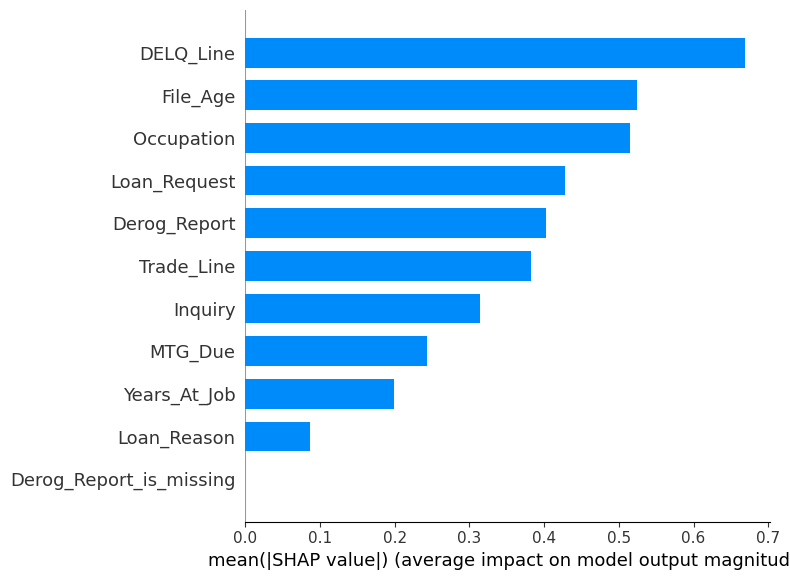

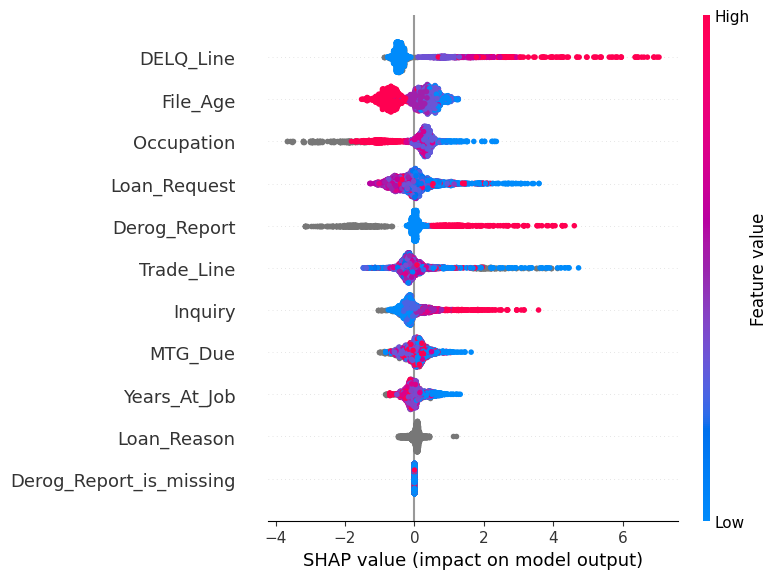

In [ ]:
# SHAP (measure how much feature impacts the model's prediction)
# explainer
lgb_model3 = lgb.LGBMClassifier(random_state=42, verbosity=-1)
lgb_model3.fit(X_train, y_train, categorical_feature=['Loan_Reason'])

explainer = shap.TreeExplainer(lgb_model3)
shap_values = explainer.shap_values(X_test)

# importance plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# summary plot (beeswarm)
shap.summary_plot(shap_values, X_test)

In [ ]:
# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

filter_condition = feature_importance['importance'] <= 0.5
shap_selected_features = feature_importance[filter_condition]
shap_selected_features = shap_selected_features['feature'].tolist()
print(shap_selected_features)

['Loan_Request', 'Derog_Report', 'Trade_Line', 'Inquiry', 'MTG_Due', 'Years_At_Job', 'Loan_Reason', 'Derog_Report_is_missing']


In [ ]:
print(feature_importance)

                    feature  importance
1                 DELQ_Line    0.668891
9                  File_Age    0.524029
8                Occupation    0.515467
0              Loan_Request    0.428635
2              Derog_Report    0.402779
4                Trade_Line    0.382248
5                   Inquiry    0.313805
7                   MTG_Due    0.243068
10             Years_At_Job    0.199625
3               Loan_Reason    0.086824
6   Derog_Report_is_missing    0.000000


In [ ]:
print(len(rfe_selected_features))
print(len(shap_selected_features))
set1 = set(rfe_selected_features)
set2 = set(shap_selected_features)
print(set1 - set2)
print(set2 - set1)

10
8
{'DELQ_Line', 'Occupation', 'File_Age'}
{'Derog_Report_is_missing'}


In [ ]:
# Population Stability Index
def calculate_psi(expected, actual, buckets=10):
    # Define bins
    breakpoints = np.percentile(expected, np.arange(0, 100, 100 / buckets))

    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    psi_values = (expected_percents - actual_percents) * np.log(expected_percents / actual_percents)
    return np.sum(psi_values)

In [ ]:
print(len(X_train))
print(len(X_test))

7320
3138


In [ ]:
# feature selection
final_feature_list = shap_selected_features
X_train = X_train[final_feature_list]

X_test = X_test[final_feature_list]

In [ ]:
lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train) # evaluation during training

In [ ]:
def find_optimal(trial):
    """
    find best setting by trial
    """

    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'verbose': -1, # less logging output

        'feature_pre_filter': False, # need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`
        # LightGBMError: Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.

        # --- hyperparameters

        # num_leaves controls model complexity.
        'num_leaves': trial.suggest_int('num_leaves', 28, 31),

        # try 0.05 to 0.1
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.065, log=True),

        # try between 0.7 and 0.8
        'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 0.8),

        # try between 0.7 and 0.8
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.7, 0.8),
        'bagging_freq': 1,

        'lambda_l1': trial.suggest_float('lambda_l1', 2e-6, 1.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 2e-6, 1.0, log=True),

        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
    }

    N_SPLITS = 5 # 5-Fold Split
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    fold_scores = []
    for fold, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
        X_train_data, X_test_data = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_data, y_test_data = y_train.iloc[train_index], y_train.iloc[test_index]

        lgb_train = lgb.Dataset(X_train_data, label=y_train_data)
        lgb_eval = lgb.Dataset(X_test_data, label=y_test_data)

        # Training
        model = lgb.train(
            params,
            lgb_train,
            num_boost_round=1000, # A cap for boosting times
            valid_sets=[lgb_eval],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50) # early stopping, avoid needless computation
            ]
        )
        # valid_sets[0] - score from the test_data
        # metric 'binary_logloss'
        fold_scores.append(model.best_score['valid_0']['binary_logloss'])

    # Return the AVERAGE score to Optuna
    return np.mean(fold_scores)

In [ ]:
# lgb_train = lgb.Dataset(X_train, y_train)  # must refresh and recreate datasets every trial
# lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)


# study = optuna.create_study(direction='minimize')
# study.optimize(find_optimal, n_trials=100)
# print(f"Best setting value: {study.best_value}")

# best_setting = study.best_params
# best_setting['objective'] = 'binary'
# best_setting['metric'] = 'binary_logloss'
# best_setting['boosting_type'] = 'gbdt'
# print("\nHyperparameters:")
# print(best_setting)

In [ ]:
# hyperparameters using the best setting we found
best_setting = {'num_leaves': 31, 'learning_rate': 0.05985699, 'feature_fraction': 0.78, 'bagging_fraction': 0.79, 'lambda_l1': 0.00017799946635990575, 'lambda_l2': 4.839414337936614e-05, 'min_child_samples': 12, 'objective': 'binary', 'metric': 'binary_logloss', 'boosting_type': 'gbdt'}
params = best_setting
lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

# Train the ultimate model
gbm_model = lgb.train(params,\
                lgb_train,\
                num_boost_round=1500,\
                valid_sets=lgb_eval,\
                callbacks=[lgb.early_stopping(50)])

print(f"Best iteration: {gbm_model.best_iteration}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1033]	valid_0's binary_logloss: 0.135787
Best iteration: 1033


In [ ]:
# Model Validation
y_pred_proba = gbm_model.predict(X_test, num_iteration=gbm_model.best_iteration)

Plotting importance based on 'split'...


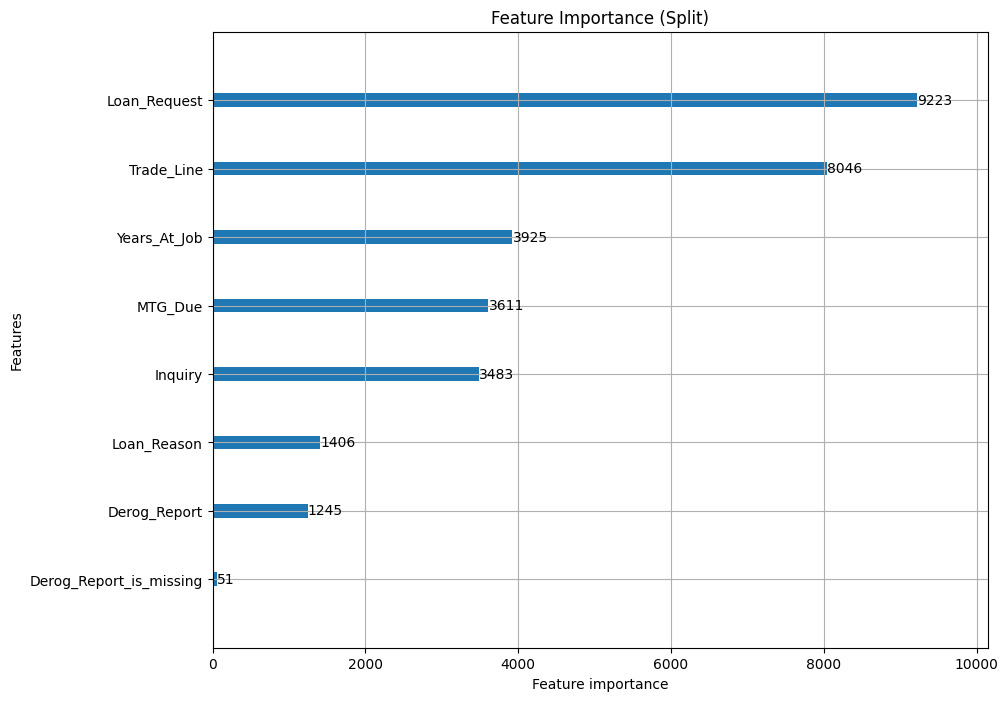

Plotting importance based on 'gain'...


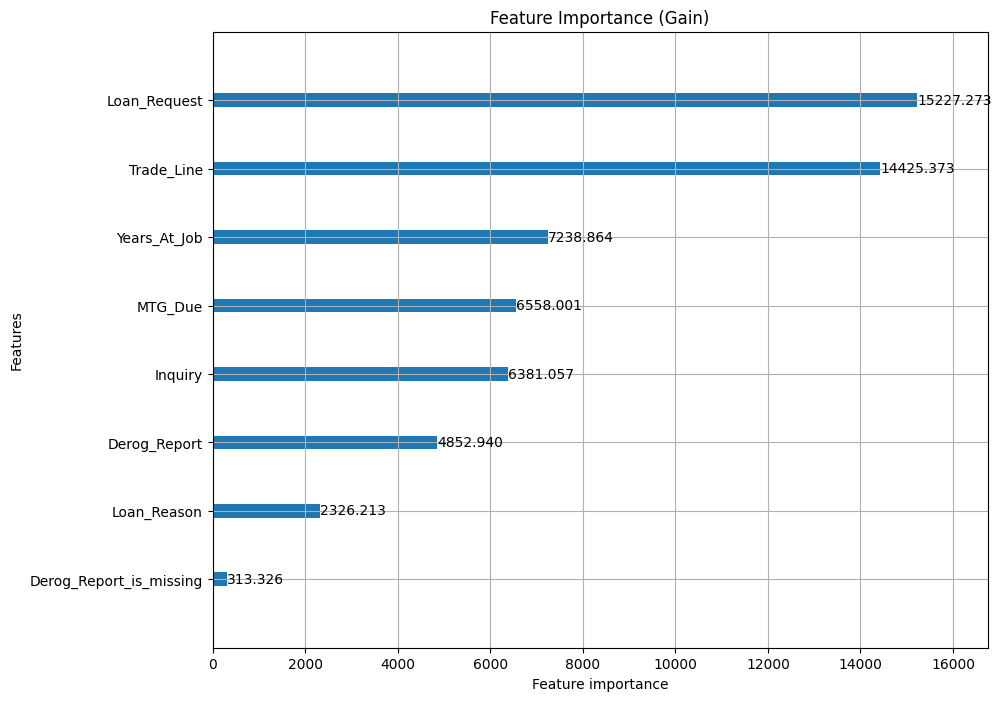

In [ ]:
# You can get the raw importance values (default is 'split')
importance_split = gbm_model.feature_importance(importance_type='split')
# Get 'gain' importance
importance_gain = gbm_model.feature_importance(importance_type='gain')

# Or, the easiest way is to just plot them:
print("Plotting importance based on 'split'...")
lgb.plot_importance(gbm_model, importance_type='split', max_num_features=15, figsize=(10, 8))
plt.title("Feature Importance (Split)")
plt.show()

print("Plotting importance based on 'gain'...")
lgb.plot_importance(gbm_model, importance_type='gain', max_num_features=15, figsize=(10, 8))
plt.title("Feature Importance (Gain)")
plt.show()

In [ ]:
# get the internal node of trees (Questions)
tree_df = gbm_model.booster_.trees_to_dataframe()
print(tree_df.head())

# Plot the tree by index (tree_index = 0)
# plt.figure(figsize=(20, 10))
# lgb.plot_tree(model, tree_index=0, show_info=['split_gain'])
# plt.show()

In [ ]:
sample_data = X_test.iloc[[0]]
# (which leaf node the data point landed)
leaf_indices = gbm_model.predict(sample_data, pred_leaf=True)[0]
# 3. Print leaf indices (which leaves the data point went through)
print(f"Leaf indices for model's trees:\n{leaf_indices}")

In [ ]:
preds_df = pd.DataFrame(y_pred_proba, columns = ['prob_bad'])
preds_df['bad_status'] = preds_df['prob_bad'].apply(lambda x: 1 if x > 0.5 else 0)
y_test_df = pd.DataFrame(np.array(y_test), columns = ['bad_status'])
preds_df['bad_status'] = preds_df['bad_status'].apply(lambda x: 1 if x > 0.5 else 0)
# Print the classification report
target_names = ['Good', 'Bad']
print(classification_report(y_test_df['bad_status'], preds_df['bad_status'], target_names=target_names))

              precision    recall  f1-score   support

        Good       0.96      0.99      0.97      2557
         Bad       0.93      0.83      0.88       581

    accuracy                           0.96      3138
   macro avg       0.95      0.91      0.93      3138
weighted avg       0.96      0.96      0.96      3138



In [ ]:
conf_mat = confusion_matrix(y_test_df['bad_status'], preds_df['bad_status'])
print("Confusion Matrix:\n", conf_mat)

Confusion Matrix:
 [[2521   36]
 [  96  485]]


In [ ]:
precision, recall, fscore, support = precision_recall_fscore_support(
    y_test_df['bad_status'], preds_df['bad_status'], average=None
)
print("Bad Precision:", precision[1])
print("Bad Recall:", recall[1])
print("Bad F-Score:", fscore[1])
print("Bad Support:", support[1])

Bad Precision: 0.9309021113243762
Bad Recall: 0.8347676419965576
Bad F-Score: 0.8802177858439202
Bad Support: 581


In [ ]:
print("Valid Metrics:")
# AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC: {auc:.4f}")

Valid Metrics:
AUC: 0.9707


In [ ]:
# Gini
gini = (2 * auc) - 1
print(f"Gini Coefficient: {gini:.4f}")

Gini Coefficient: 0.9415


In [ ]:
# K-S Statistic
# separate scores for bads and goods
bads = y_pred_proba[y_test == 1]
goods = y_pred_proba[y_test == 0]

ks_statistic, ks_pvalue = ks_2samp(bads, goods)
print(f"K-S Statistic: {ks_statistic:.4f}")
print(f"K-S P-Value:   {ks_pvalue}")

K-S Statistic: 0.8590
K-S P-Value:   5.3e-322


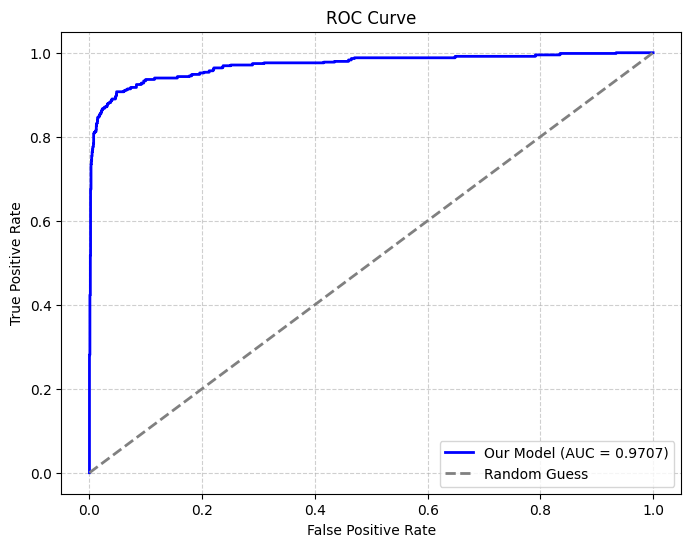

In [ ]:
# ROC AUC Plot
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
# Plot the model's ROC curve
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'Our Model (AUC = {auc:.4f})')

# random guess
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
         label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# fraction_of_positives is actual default rate in the bin
# mean_predicted_value is average predicted probability in the bin
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='uniform')

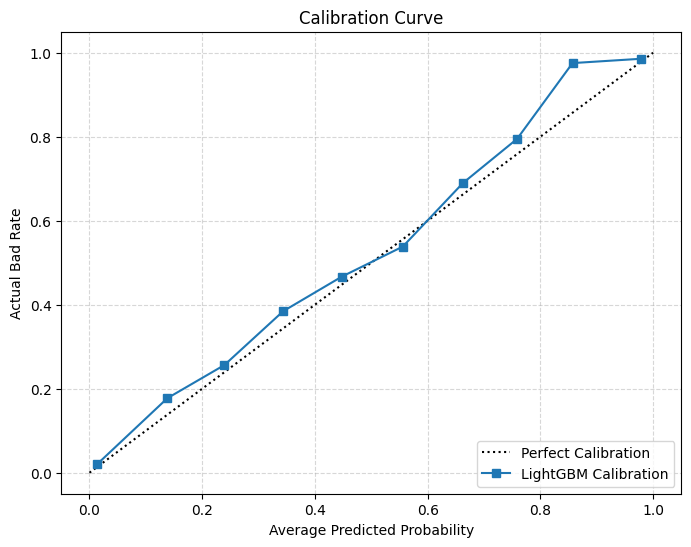

In [ ]:
# visualizaiton Calibration Curve
plt.figure(figsize=(8, 6))
# perfect calibration
plt.plot([0, 1], [0, 1], "k:", label="Perfect Calibration")

# Plot the model's calibration curve
plt.plot(mean_predicted_value, fraction_of_positives, "s-",
         label="LightGBM Calibration")

plt.xlabel("Average Predicted Probability")
plt.ylabel("Actual Bad Rate")
plt.title("Calibration Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

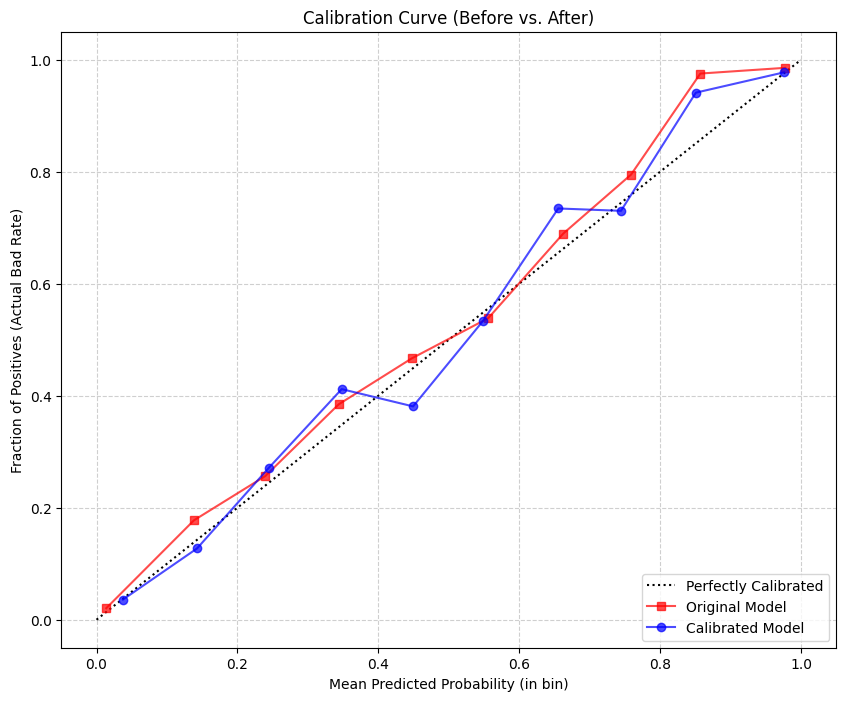

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

base_model = lgb.LGBMClassifier(**params)
calibrated_model = CalibratedClassifierCV(base_model,
                                        method='isotonic',
                                        cv=5, # 5 is a good default
                                        n_jobs=-1) # Use all CPU cores
calibrated_model.fit(X_train, y_train)
y_pred_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]
fop_uncal, mpv_uncal = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='uniform')
fop_cal, mpv_cal = calibration_curve(y_test, y_pred_proba_calibrated, n_bins=10, strategy='uniform')
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

# Plot the "BEFORE" curve
plt.plot(mpv_uncal, fop_uncal, "s-", label="Original Model", color='red', alpha=0.7)

# Plot the "AFTER" curve
plt.plot(mpv_cal, fop_cal, "o-", label="Calibrated Model", color='blue', alpha=0.7)

plt.xlabel("Mean Predicted Probability (in bin)")
plt.ylabel("Fraction of Positives (Actual Bad Rate)")
plt.title("Calibration Curve (Before vs. After)")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
metrics_df = pd.DataFrame({
    'ground_truth': y_test,
    'pred_proba': y_pred_proba
})

# Sort df in desc order
metrics_df = metrics_df.sort_values(by='pred_proba', ascending=False)
metrics_df = metrics_df.reset_index(drop=True)


metrics_df['decile'] = pd.qcut(
    metrics_df['pred_proba'],
    q=10, # num of deciles
    labels=range(10, 0, -1), # Use integer labels
    duplicates='drop'
)

metrics_df['decile'] = metrics_df['decile'].apply(lambda x: 10 - x) # 1-highest risk, 10-lowest risk


total_population = metrics_df['ground_truth'].count()
total_bads = metrics_df['ground_truth'].sum()
total_goods = total_population - total_bads

metrics_df['population_pct'] = (np.arange(1, total_population + 1)) / total_population
metrics_df['cumulative_bads_count'] = metrics_df['ground_truth'].cumsum()
metrics_df['cumulative_goods_count'] = (1 - metrics_df['ground_truth']).cumsum()

metrics_df['cumulative_gain_pct'] = metrics_df['cumulative_bads_count'] / total_bads
metrics_df['cumulative_goods_pct'] = metrics_df['cumulative_gain_pct'] / total_goods

In [ ]:
bad_rate = total_bads / total_population
print(f"Overall Bad Rate: {bad_rate:.4f}")

Overall Bad Rate: 0.1851


In [ ]:
good_rate = total_goods / total_population
print(f"Overall Good Rate: {good_rate:.4f}")

Overall Good Rate: 0.8149


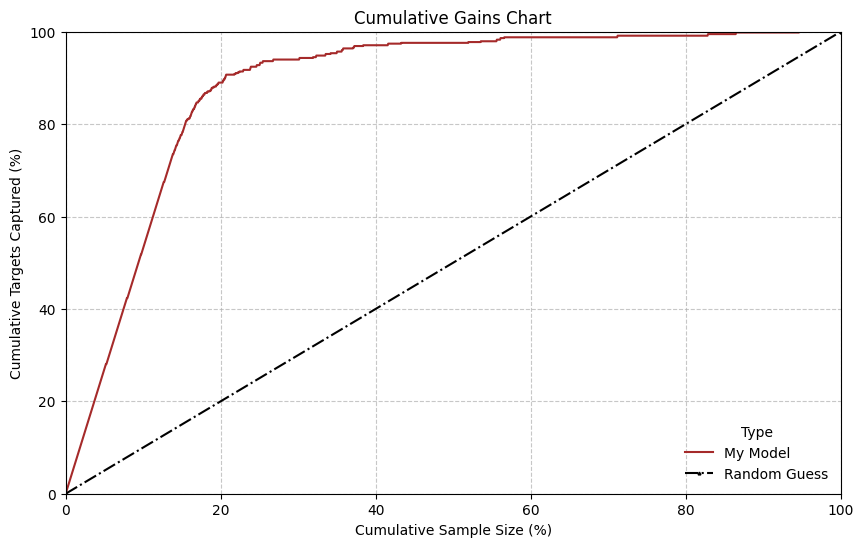

In [ ]:
# Cumulative Gains Chart
plt.figure(figsize=(10, 6))

plt.plot(metrics_df['population_pct'] * 100,
         metrics_df['cumulative_gain_pct'] * 100,
         markersize=0.1, linestyle='-', color='brown',
         label='My Model')

plt.plot([0, 100], [0, 100], 'k-.',
         marker='^', markersize=2,
         label='Random Guess')

plt.xlabel('Cumulative Population Size (%)')
plt.ylabel('Cumulative Targets Captured (%)')
plt.title('Cumulative Gains Chart')
plt.legend(title='Type', loc='lower right', frameon=False)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 100) # Ensure x-axis 0-100%
plt.ylim(0, 100) # Ensure y-axis 0-100%
plt.show()

**By targeting the top 20% of customers as ranked by my model, it captures over 90% of all the 'Bads**

/tmp/ipython-input-4171974573.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bad_rate_by_decile = metrics_df.groupby('decile')['ground_truth'].agg(


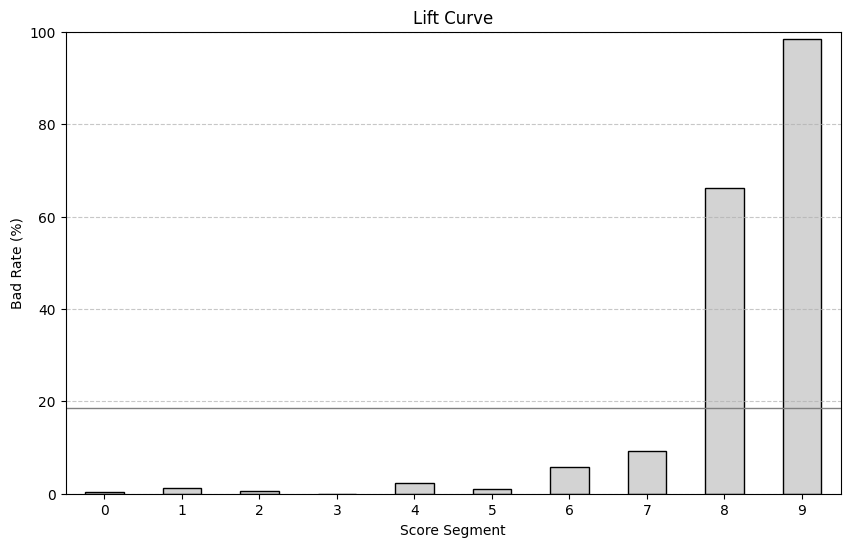

In [ ]:
# Lift Curve
bad_rate_by_decile = metrics_df.groupby('decile')['ground_truth'].agg(
    total_in_decile='count',
    bads_in_decile='sum'
)
bad_rate_by_decile['bad_rate_pct'] = (bad_rate_by_decile['bads_in_decile'] /
                                       bad_rate_by_decile['total_in_decile']) * 100

plt.figure(figsize=(10, 6))
bad_rate_by_decile['bad_rate_pct'].plot(kind='bar', color='lightgray', edgecolor='black')

plt.axhline(y=(total_bads / total_population) * 100, color='gray', linestyle='-', lw=1) # Overall bad rate line

plt.xlabel('Score Segment')
plt.ylabel('Bad Rate (%)')
plt.title('Lift Curve')
plt.xticks(rotation=0) # horizontal segment labels
plt.ylim(0, 100) # y-axis from 0 to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(metrics_df['cumulative_goods_pct'].head(5))
print()
print(metrics_df['cumulative_gain_pct'].head(5))

0    6.731210e-07
1    1.346242e-06
2    2.019363e-06
3    2.692484e-06
4    3.365605e-06
Name: cumulative_goods_pct, dtype: float64

0    0.001721
1    0.003442
2    0.005164
3    0.006885
4    0.008606
Name: cumulative_gain_pct, dtype: float64


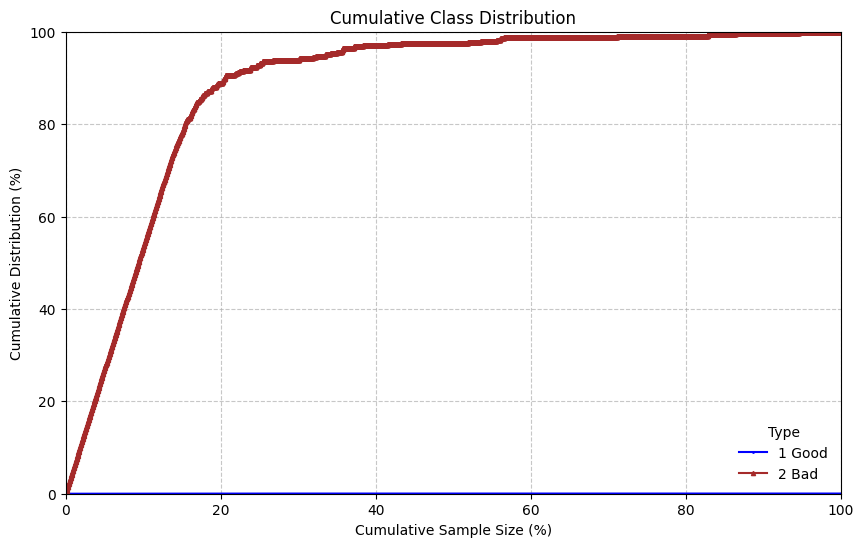

In [ ]:
# Cumulative Class Distribution (K-S plot)
plt.figure(figsize=(10, 6))

# Plot cumulative Goods distribution
plt.plot(metrics_df['population_pct'] * 100,
         metrics_df['cumulative_goods_pct'] * 100,
         marker='o', markersize=1, linestyle='-', color='blue',
         label='1 Good')

# Plot cumulative Bads distribution
plt.plot(metrics_df['population_pct'] * 100,
         metrics_df['cumulative_gain_pct'] * 100,
         marker='^', markersize=3, linestyle='-', color='brown',
         label='2 Bad')

plt.xlabel('Cumulative Sample Size (%)')
plt.ylabel('Cumulative Distribution (%)')
plt.title('Cumulative Class Distribution')
plt.legend(title='Type', loc='lower right', frameon=False)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

By targeting the top 20% of customers as ranked by my model, it captures 90% of all the 'Bads

In [ ]:
# Population Stability Index
def calculate_psi(expected, actual, bins=10):


    # Create bins using training data
    _, bins = pd.qcut(expected, q=bins, retbins=True, duplicates='drop')

    # Add boundaries to capture all
    bins[0] = -np.inf
    bins[-1] = np.inf

    # Calculate % of each bin for 'expected'
    expected_pct = pd.cut(expected, bins=bins).value_counts(normalize=True)

    # Calculate % of each bin for 'actual'
    actual_pct = pd.cut(actual, bins=bins).value_counts(normalize=True)


    psi_df = pd.DataFrame({
        'Expected %': expected_pct,
        'Actual %': actual_pct
    })
    psi_df.index.name = 'Score Bin'

    # avoid divide-by-zero
    psi_df = psi_df.replace(0, 0.00001)

    # Calculate PSI
    psi_df['(Actual - Expected)'] = psi_df['Actual %'] - psi_df['Expected %']
    psi_df['ln(Actual / Expected)'] = np.log(psi_df['Actual %'] / psi_df['Expected %'])

    psi_df['PSI_Component'] = psi_df['(Actual - Expected)'] * psi_df['ln(Actual / Expected)']

    psi_value = psi_df['PSI_Component'].sum()

    return psi_value, psi_df


train_scores = gbm_model.predict(X_train, num_iteration=gbm_model.best_iteration)

test_scores = gbm_model.predict(X_test, num_iteration=gbm_model.best_iteration)
# train_scores = calibrated_model.predict(X_train)
# test_scores = calibrated_model.predict(X_test)
psi_value, psi_dataframe = calculate_psi(pd.Series(train_scores), pd.Series(test_scores))

print(f"PSI")
print(f"Total PSI: {psi_value:.6f}")
print("by Bin")
print(psi_dataframe)

PSI
Total PSI: 0.052963
by Bin
                    Expected %  Actual %  (Actual - Expected)  \
Score Bin                                                       
(-inf, 0.00049]       0.100137  0.089547            -0.010589   
(0.00049, 0.00145]    0.099863  0.087635            -0.012228   
(0.00145, 0.00272]    0.100000  0.088273            -0.011727   
(0.00272, 0.00468]    0.100137  0.084130            -0.016007   
(0.00468, 0.00765]    0.099863  0.093053            -0.006810   
(0.00765, 0.0137]     0.100000  0.102613             0.002613   
(0.0137, 0.0261]      0.100000  0.094009            -0.005991   
(0.0261, 0.0984]      0.100000  0.133843             0.033843   
(0.0984, 0.977]       0.100000  0.156150             0.056150   
(0.977, inf]          0.100000  0.070746            -0.029254   

                    ln(Actual / Expected)  PSI_Component  
Score Bin                                                 
(-inf, 0.00049]                 -0.111766       0.001184  
(0.00049, 0